# 🚀 Deepfake Detection — Attempt 11 (Cross-Attention Triple-Stream)

> **Goal:** Fix Face2Face and DFD weaknesses from Attempt 10 (DFD AUC=0.65)
> by adding Cross-Attention fusion, 16-frame temporal context, and multi-scale
> frequency analysis.

## 🔄 Changes from Attempt 10
| Component | Attempt 10 | Attempt 11 (This) | Why |
|---|---|---|---|
| Frames | 8 | **16** (from 32 reservoir) | Richer temporal signal for Face2Face |
| Temporal Layers | 2 | **3** | Deeper motion modeling |
| Fusion | Concatenation | **Cross-Attention + Concat** | Streams "talk" to each other |
| Frequency | Single high-pass (k=7) | **Multi-scale (k=3,7,15)** | Catches DFD's subtle artifacts |
| Batch Size | 4 | **2** (accum=8) | VRAM budget for 16 frames |
| DFD Weight | 1.0x | **1.5x** | Forces learning DFD patterns |
| Mixup | None | **α=0.2** | Stronger regularization |
| EMA | None | **decay=0.999** | Smoother convergence |
| Warmup | 30% | **35%** | Even gentler ramp for larger model |

## 📋 Sections
| # | Section |
|---|---|
| 1 | Environment Setup |
| 2 | Imports & Config |
| 3 | Device Setup |
| 4 | Dataset Loading (Pre-extracted .pt) |
| 5 | Train / Val / Test Split |
| 6 | Frame Loading & RAM Caching |
| 7 | Dataset & DataLoaders |
| 8 | **Triple-Stream Model Architecture** |
| 9 | Focal Loss & Utilities (Mixup & EMA) |
| 10 | Model Initialization |
| 11 | Training Loop |
| 12 | Comprehensive Evaluation |
| 13 | Single-Video Inference |
| 14 | Raw .mp4 Video Inference |


---
## 🔧 Section 1 — Environment Setup
> ⚠️ After running this cell, **Restart Session** before continuing.

In [5]:
import subprocess, sys

def run(cmd):
    print('>>', ' '.join(cmd))
    subprocess.check_call(cmd)

print('Upgrading pip...')
run([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', 'pip'])

print('Installing P100-compatible PyTorch...')
run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'torch==2.3.1', 'torchvision==0.18.1', 'torchaudio==2.3.1',
    '--index-url', 'https://download.pytorch.org/whl/cu118'
])

print('Installing requirements...')
run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'timm', 'albumentations', 'opencv-python-headless',
    'scikit-learn', 'matplotlib', 'seaborn', 'pandas', 'tqdm', 'kagglehub'
])

print('✅ Setup complete. 🛑 Restart Session now.')

Upgrading pip...
>> /usr/bin/python3 -m pip install -q --upgrade pip
Installing P100-compatible PyTorch...
>> /usr/bin/python3 -m pip install -q torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 --index-url https://download.pytorch.org/whl/cu118
Installing requirements...
>> /usr/bin/python3 -m pip install -q timm albumentations opencv-python-headless scikit-learn matplotlib seaborn pandas tqdm kagglehub
✅ Setup complete. 🛑 Restart Session now.


---
## 📦 Section 2 — Imports & Configuration

### Key changes vs Attempt 10
| Parameter | Attempt 10 | Attempt 11 | Rationale |
|---|---|---|---|
| `num_frames` | 8 | **16** | Richer temporal context |
| `train_bs` | 4 | **2** | VRAM budget for 16 frames |
| `accum_steps` | 4 | **8** | Keep effective batch size at 16 |
| `dfd_weight_boost` | N/A | **1.5** | Over-sample DFD to force learning its patterns |
| `mixup_alpha` | N/A | **0.2** | Blends video pairs for stronger regularization |
| `ema_decay` | N/A | **0.999** | Smoother convergence |

In [6]:
import os, gc, math, random, time, copy
from pathlib import Path
from dataclasses import dataclass

print('Importing core libraries ...')
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

import timm
import albumentations as A
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

print(f'  torch: {torch.__version__}  |  timm: {timm.__version__}')

@dataclass
class CFG:
    seed: int            = 42
    img_size: int        = 224
    num_frames: int      = 16          # ← 8→16 (from 32-frame reservoir)
    reservoir_frames: int = 32         # Total frames stored per .pt file
    train_bs: int        = 2           # ← 4→2 (VRAM budget for 16 frames)
    val_bs: int          = 4           # ← 8→4
    num_workers: int     = 4
    epochs: int          = 35
    lr: float            = 3e-5
    wd: float            = 0.1
    max_grad_norm: float = 1.0
    backbone: str        = 'deit_small_patch16_224'
    dropout: float       = 0.4
    drop_path_rate: float = 0.2
    label_smoothing: float = 0.05
    use_focal: bool      = True
    focal_gamma: float   = 2.0
    early_stopping_patience: int = 12  # ← 10→12 (more patience for deeper model)
    target_acc: float    = 0.95
    accum_steps: int     = 8           # ← 4→8 (effective BS = 2×8 = 16)
    max_train_per_source: int = 0
    cache_frames: bool   = False       # ← Turned off for 32-frame dataset (too big for RAM)
    freq_dim: int        = 128
    pct_start: float     = 0.35        # ← 0.30→0.35 (longer warmup)
    mixup_alpha: float   = 0.2         # NEW: Mixup strength
    ema_decay: float     = 0.999       # NEW: EMA decay
    dfd_weight_boost: float = 1.5      # NEW: DFD over-sampling factor
    cross_attn_heads: int = 6          # NEW: Cross-attention heads

cfg = CFG()
print('\n' + '─'*60)
print('  ⚙️  Configuration (Attempt 11 — Cross-Attention)')
print('─'*60)
for field, val in cfg.__dict__.items():
    print(f'  {field:<30}: {val}')
print('─'*60)
print('  ✅ CFG loaded.')

Importing core libraries ...
  torch: 2.3.1+cu118  |  timm: 1.0.25

────────────────────────────────────────────────────────────
  ⚙️  Configuration (Attempt 11 — Cross-Attention)
────────────────────────────────────────────────────────────
  seed                          : 42
  img_size                      : 224
  num_frames                    : 16
  reservoir_frames              : 32
  train_bs                      : 2
  val_bs                        : 4
  num_workers                   : 4
  epochs                        : 35
  lr                            : 3e-05
  wd                            : 0.1
  max_grad_norm                 : 1.0
  backbone                      : deit_small_patch16_224
  dropout                       : 0.4
  drop_path_rate                : 0.2
  label_smoothing               : 0.05
  use_focal                     : True
  focal_gamma                   : 2.0
  early_stopping_patience       : 12
  target_acc                    : 0.95
  accum_steps           

---
## 🌱 Section 3 — Device Setup

In [7]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark     = True

seed_everything(cfg.seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️ Device : {device}')
if torch.cuda.is_available():
    print(f'🎮 GPU    : {torch.cuda.get_device_name(0)}')
    print(f'💾 VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

🖥️ Device : cuda
🎮 GPU    : Tesla P100-PCIE-16GB
💾 VRAM   : 17.1 GB


---
## 📂 Section 4 — Dataset Loading (Pre-extracted .pt Frames)

Downloads the pre-extracted `.pt` frames using KaggleHub.

In [8]:
import kagglehub
import time
from pathlib import Path
import pandas as pd
import os

# ── UPDATE THIS to your new 32-frame dataset ──
DATASET_NAME = "nightfury22344/new-dataset-11"  # ← Change if you uploaded under different name
print(f"Downloading dataset '{DATASET_NAME}'...")
dataset_path = kagglehub.dataset_download(DATASET_NAME)

pt_dir = Path(dataset_path)
print(f'Scanning pre-extracted .pt files from:\n  {pt_dir}\n')
t0 = time.time()

if not pt_dir.exists():
    raise FileNotFoundError(f'Directory not found: {pt_dir}')

all_files = list(pt_dir.rglob('*'))
print(f"Total files found in dataset root: {len(all_files)}")
if len(all_files) > 0:
    print(f"First 5 files found: {[str(f.name) for f in all_files[:5]]}")

rows = []
for pt_file in sorted(pt_dir.rglob('*.pt')):
    parts = pt_file.stem.split('_', 2)
    if len(parts) < 3:
        continue
    source, label_str, stem = parts[0], parts[1], parts[2]
    if label_str not in ('0', '1'):
        continue
    rows.append({
        'pt_path' : str(pt_file),
        'label'   : int(label_str),
        'source'  : source,
        'identity': f'{source}_{stem[:12]}',
    })

if not rows:
    raise RuntimeError(f"No valid .pt files found!")

df = pd.DataFrame(rows)
vc = df['label'].value_counts().to_dict()
print(f'  Total .pt files : {len(df)}')
print(f'  Real  (0)       : {vc.get(0, 0)}')
print(f'  Fake  (1)       : {vc.get(1, 0)}')
print(f'  Sources         : {df["source"].value_counts().to_dict()}')
print(f'  Scan time       : {time.time()-t0:.2f}s')

# Quick check: verify frame count in first file
sample_data = torch.load(rows[0]['pt_path'], map_location='cpu', weights_only=False)
actual_frames = sample_data['frames'].shape[0]
print(f'  Frames per file : {actual_frames} (expected {cfg.reservoir_frames})')
if actual_frames < cfg.num_frames:
    print(f'  ⚠️ WARNING: Files have {actual_frames} frames but cfg.num_frames={cfg.num_frames}!')
    print(f'  Will pad with duplicates during training.')
print('  ✅ Dataset metadata loaded.')
df.head()

Scanning pre-extracted .pt files from:
  /kaggle/input/datasets/nightfury22344/new-dataset-11

Total files found in dataset root: 12862
First 5 files found: ['celebdf_1_id50_id52_0003.pt', 'dfd_1_03_13__hugging_happy__GBYWJW06.pt', 'celebdf_1_id28_id35_0005.pt', 'celebdf_1_id31_id6_0005.pt', 'celebdf_0_00069.pt']
  Total .pt files : 12862
  Real  (0)       : 2253
  Fake  (1)       : 10609
  Sources         : {'celebdf': 6529, 'dfd': 3344, 'ffpp': 2989}
  Scan time       : 15.05s
  Frames per file : 32 (expected 32)
  ✅ Dataset metadata loaded.


,pt_path,label,source,identity
0,/kaggle/input/datasets/nightfury22344/new-data...,0,celebdf,celebdf_00000
1,/kaggle/input/datasets/nightfury22344/new-data...,0,celebdf,celebdf_00001
2,/kaggle/input/datasets/nightfury22344/new-data...,0,celebdf,celebdf_00002
3,/kaggle/input/datasets/nightfury22344/new-data...,0,celebdf,celebdf_00003
4,/kaggle/input/datasets/nightfury22344/new-data...,0,celebdf,celebdf_00004


---
## ✂️ Section 5 — Train / Val / Test Split

In [9]:
print('Splitting by identity ...')
t0 = time.time()

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=cfg.seed)
train_idx, temp_idx = next(gss.split(df, groups=df['identity']))
train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df  = df.iloc[temp_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=cfg.seed)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df['identity']))
val_df   = temp_df.iloc[val_idx].reset_index(drop=True)
test_df  = temp_df.iloc[test_idx].reset_index(drop=True)

assert not set(train_df['identity']) & set(val_df['identity'])
assert not set(train_df['identity']) & set(test_df['identity'])

if cfg.max_train_per_source > 0:
    parts = []
    for src, grp in train_df.groupby('source'):
        if len(grp) > cfg.max_train_per_source:
            real_g = grp[grp['label'] == 0]
            fake_g = grp[grp['label'] == 1]
            n_real = min(len(real_g), cfg.max_train_per_source // 2)
            n_fake = min(len(fake_g), cfg.max_train_per_source - n_real)
            sampled = pd.concat([
                real_g.sample(n_real, random_state=cfg.seed),
                fake_g.sample(n_fake, random_state=cfg.seed)
            ])
            parts.append(sampled)
        else:
            parts.append(grp)
    train_df = pd.concat(parts).sample(frac=1, random_state=cfg.seed).reset_index(drop=True)
else:
    print('  ℹ️  No capping — using ALL training data.')

for name, sdf in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    vc = sdf['label'].value_counts().to_dict()
    src_counts = sdf['source'].value_counts().to_dict()
    print(f'  {name:<6}: {len(sdf):>5} samples | real={vc.get(0,0):>4} fake={vc.get(1,0):>4} | {src_counts}')
print(f'  ✅ Split done in {time.time()-t0:.2f}s')

Splitting by identity ...
  ℹ️  No capping — using ALL training data.
  Train : 10354 samples | real=1788 fake=8566 | {'celebdf': 5252, 'dfd': 2693, 'ffpp': 2409}
  Val   :  1277 samples | real= 239 fake=1038 | {'celebdf': 658, 'dfd': 324, 'ffpp': 295}
  Test  :  1231 samples | real= 226 fake=1005 | {'celebdf': 619, 'dfd': 327, 'ffpp': 285}
  ✅ Split done in 0.03s


---
## 💾 Section 6 — Frame Loading & RAM Caching

Loads pre-extracted `.pt` tensors into RAM for zero-disk-IO training.

In [10]:
def load_pt_cache(df_split, desc='Loading') -> dict:
    cache = {}
    errors = []
    paths = df_split['pt_path'].tolist()

    def _load(p):
        try:
            data = torch.load(p, map_location='cpu', weights_only=False)
            return p, data['frames'].numpy()
        except Exception as e:
            return p, None

    from concurrent.futures import ThreadPoolExecutor, as_completed
    with ThreadPoolExecutor(max_workers=cfg.num_workers) as pool:
        futures = {pool.submit(_load, p): p for p in paths}
        pbar = tqdm(as_completed(futures), total=len(futures),
                    desc=f'  {desc}', unit='file')
        for fut in pbar:
            p, arr = fut.result()
            if arr is not None:
                cache[p] = arr
            else:
                errors.append(p)

    if errors:
        print(f'  ⚠️  {len(errors)} files failed to load.')
    return cache

print('Loading pre-extracted frames into RAM ...')
t0 = time.time()

if cfg.cache_frames:
    train_cache = load_pt_cache(train_df, desc='Train cache')
    val_cache   = load_pt_cache(val_df,   desc='Val cache  ')
    test_cache  = load_pt_cache(test_df,  desc='Test cache ')
else:
    print('  ⏭️ Skipping RAM cache to save memory (loading from disk dynamically)')
    train_cache, val_cache, test_cache = {}, {}, {}

total_loaded = len(train_cache) + len(val_cache) + len(test_cache)
total_samples = len(train_df) + len(val_df) + len(test_df)
# Estimate RAM: each file has reservoir_frames × 224 × 224 × 3 bytes
ram_gb = total_loaded * cfg.reservoir_frames * cfg.img_size * cfg.img_size * 3 / 1e9

print(f'\n  ✅ Loaded {total_loaded}/{total_samples} samples in {(time.time()-t0)/60:.1f} min')
print(f'  💾 Est. RAM used: ~{ram_gb:.1f} GB')
print(f'  train={len(train_cache)} | val={len(val_cache)} | test={len(test_cache)}')

Loading pre-extracted frames into RAM ...
  ⏭️ Skipping RAM cache to save memory (loading from disk dynamically)

  ✅ Loaded 0/12862 samples in 0.0 min
  💾 Est. RAM used: ~0.0 GB
  train=0 | val=0 | test=0


---
## 🎞️ Section 7 — Dataset & DataLoaders

**NEW in Attempt 11:**
- **16-frame sampling**: Randomly samples a 16-frame contiguous window from the 32-frame reservoir during training.
- **DFD Boost**: Samples from the `dfd` source are weighted 1.5x higher during training.

In [11]:
class CachedVideoDataset(Dataset):
    _MEAN = np.array([0.485, 0.456, 0.406], np.float32)
    _STD  = np.array([0.229, 0.224, 0.225], np.float32)

    def __init__(self, df, cache, img_size=224, num_frames=16, train_mode=True):
        self.df         = df.reset_index(drop=True)
        self.cache      = cache
        self.img_size   = img_size
        self.num_frames = num_frames
        self.train_mode = train_mode

        if train_mode:
            self.aug = A.Compose([
                A.RandomResizedCrop(
                    size=(img_size, img_size),
                    scale=(0.8, 1.0),
                    ratio=(0.9, 1.1),
                    p=1.0
                ),
                A.HorizontalFlip(p=0.5),
                A.ShiftScaleRotate(
                    shift_limit=0.05, scale_limit=0.05, rotate_limit=15,
                    border_mode=cv2.BORDER_CONSTANT, p=0.4
                ),
                A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
                A.ImageCompression(quality_range=(50, 95), p=0.3),
                A.GaussNoise(p=0.2),
                A.CoarseDropout(num_holes_range=(1, 4), hole_height_range=(16, 40),
                                hole_width_range=(16, 40), p=0.3),
                A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.3),
                A.GaussianBlur(blur_limit=(3, 5), p=0.2),
            ])
        else:
            self.aug = None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        pt_path = row['pt_path']

        if pt_path in self.cache:
            frames = self.cache[pt_path].copy()
        else:
            try:
                data   = torch.load(pt_path, map_location='cpu', weights_only=False)
                frames = data['frames'].numpy()
            except Exception:
                frames = np.zeros((self.num_frames, self.img_size, self.img_size, 3), np.uint8)

        T = frames.shape[0]
        if self.train_mode and T > self.num_frames:
            # Random contiguous window from the 32-frame reservoir
            start = np.random.randint(0, T - self.num_frames + 1)
            frames = frames[start : start + self.num_frames]
        elif T > self.num_frames:
            # Evenly spaced for val/test
            idxs = np.linspace(0, T - 1, self.num_frames, dtype=int)
            frames = frames[idxs]
        elif T < self.num_frames:
            # Pad by repeating last frame
            pad = np.stack([frames[-1]] * (self.num_frames - T))
            frames = np.concatenate([frames, pad], axis=0)

        if self.aug is not None:
            frames = np.stack([self.aug(image=f)['image'] for f in frames])

        x = frames.astype(np.float32) / 255.0
        x = (x - self._MEAN) / self._STD
        x = np.transpose(x, (0, 3, 1, 2))
        return torch.tensor(x), torch.tensor(np.float32(row['label']))


# ─── Build datasets ────────────────────────────────────────────────
train_ds = CachedVideoDataset(train_df, train_cache, cfg.img_size, cfg.num_frames, train_mode=True)
val_ds   = CachedVideoDataset(val_df,   val_cache,   cfg.img_size, cfg.num_frames, train_mode=False)
test_ds  = CachedVideoDataset(test_df,  test_cache,  cfg.img_size, cfg.num_frames, train_mode=False)

# Weighted sampler with DFD boost
train_labels   = train_df['label'].values.astype(int)
train_sources  = train_df['source'].values
class_counts   = np.bincount(train_labels, minlength=2)
class_weights  = class_counts.sum() / np.clip(class_counts, 1, None)
sample_weights = class_weights[train_labels].copy()

# Boost DFD samples by 1.5x
dfd_mask = train_sources == 'dfd'
sample_weights[dfd_mask] *= cfg.dfd_weight_boost
print(f'  DFD samples boosted by {cfg.dfd_weight_boost}x ({dfd_mask.sum()} samples)')

sampler = WeightedRandomSampler(torch.DoubleTensor(sample_weights), len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=cfg.train_bs, sampler=sampler,
                          num_workers=cfg.num_workers, pin_memory=True, drop_last=True,
                          persistent_workers=True, prefetch_factor=2)
val_loader   = DataLoader(val_ds,   batch_size=cfg.val_bs, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True,
                          persistent_workers=True, prefetch_factor=2)
test_loader  = DataLoader(test_ds,  batch_size=cfg.val_bs, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True,
                          persistent_workers=True, prefetch_factor=2)

print(f'  Train: {len(train_ds)} samples | {len(train_loader)} batches')
print(f'  Val:   {len(val_ds)} samples   | {len(val_loader)} batches')
print(f'  Test:  {len(test_ds)} samples  | {len(test_loader)} batches')
print(f'  Class weights: real={class_weights[0]:.2f}  fake={class_weights[1]:.2f}')
print(f'  Effective batch size: {cfg.train_bs} × {cfg.accum_steps} = {cfg.train_bs * cfg.accum_steps}')
print('  ✅ DataLoaders ready.')

  DFD samples boosted by 1.5x (2693 samples)
  Train: 10354 samples | 5177 batches
  Val:   1277 samples   | 320 batches
  Test:  1231 samples  | 308 batches
  Class weights: real=5.79  fake=1.21
  Effective batch size: 2 × 8 = 16
  ✅ DataLoaders ready.


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


---
## 🧠 Section 8 — Triple-Stream Model Architecture

### Upgrades vs Attempt 10
- **Temporal Stream**: Transformer encoder increased from 2 to **3 layers**.
- **Cross-Attention Bridge**: Bidirectional attention between Spatial and Temporal streams.
- **Frequency Stream**: Upgraded to use **Multi-Scale High-Pass** (kernels 3, 7, 15).

In [12]:
class MultiScaleFrequencyStream(nn.Module):
    """Stream 3 V2: Multi-scale high-pass filtering for diverse artifacts."""
    def __init__(self, out_dim=128):
        super().__init__()
        # Three parallel high-pass filters at different scales
        self.scales = [3, 7, 15]

        # Shared CNN backbone after concatenation
        self.conv = nn.Sequential(
            nn.Conv2d(3 * len(self.scales), 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.GELU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )
        self.proj = nn.Linear(256, out_dim)

    def multi_scale_high_pass(self, x):
        """x: [B, 3, H, W] → multi-scale high-frequency residuals [B, 9, H, W]"""
        residuals = []
        for k in self.scales:
            blurred = F.avg_pool2d(x, kernel_size=k, stride=1, padding=k // 2)
            residuals.append(x - blurred)
        return torch.cat(residuals, dim=1)  # [B, 3*3, H, W] = [B, 9, H, W]

    def forward(self, frames):
        """frames: [B, T, C, H, W] → [B, out_dim]"""
        B, T, C, H, W = frames.shape
        flat = frames.view(B * T, C, H, W)
        hp   = self.multi_scale_high_pass(flat)
        feat = self.proj(self.conv(hp))
        return feat.view(B, T, -1).mean(dim=1)


class CrossAttentionBlock(nn.Module):
    """Bidirectional cross-attention: Temporal queries Spatial, and vice versa."""
    def __init__(self, dim, num_heads=6, dropout=0.1):
        super().__init__()
        self.cross_attn_t2s = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.cross_attn_s2t = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm_t = nn.LayerNorm(dim)
        self.norm_s = nn.LayerNorm(dim)
        self.ffn_t = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Dropout(dropout), nn.Linear(dim * 2, dim))
        self.ffn_s = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Dropout(dropout), nn.Linear(dim * 2, dim))
        self.norm_t2 = nn.LayerNorm(dim)
        self.norm_s2 = nn.LayerNorm(dim)

    def forward(self, spatial_feat, temporal_feat):
        """
        spatial_feat:  [B, 384]
        temporal_feat: [B, 384]
        Returns refined spatial and temporal features.
        """
        # Expand to sequence dim for attention: [B, 1, 384]
        s = spatial_feat.unsqueeze(1)
        t = temporal_feat.unsqueeze(1)

        # Temporal attends to Spatial (Query=T, Key/Value=S)
        t_refined, _ = self.cross_attn_t2s(t, s, s)
        t = self.norm_t(t + t_refined)
        t = self.norm_t2(t + self.ffn_t(t))

        # Spatial attends to Temporal (Query=S, Key/Value=T)
        s_refined, _ = self.cross_attn_s2t(s, t, t)
        s = self.norm_s(s + s_refined)
        s = self.norm_s2(s + self.ffn_s(s))

        return s.squeeze(1), t.squeeze(1)  # [B, 384], [B, 384]


class TripleStreamDetectorV2(nn.Module):
    """Triple-Stream V2 with Cross-Attention Fusion and Multi-Scale Frequency.
       Stream 1 (Spatial)  : DeiT-Small ViT + attention pooling → 384-dim
       Stream 2 (Temporal) : Shared ViT features + 3-layer Transformer encoder → 384-dim
       Stream 3 (Frequency): Multi-scale high-pass CNN → 128-dim
       Fusion: Cross-Attention(Spatial↔Temporal) + Concat(all 3) → MLP → 1 logit
    """
    def __init__(self, backbone='deit_small_patch16_224', dropout=0.4,
                 freq_dim=128, drop_path_rate=0.2, cross_attn_heads=6):
        super().__init__()
        # ── Shared ViT backbone with Stochastic Depth ──
        self.backbone = timm.create_model(
            backbone, pretrained=True, num_classes=0,
            drop_path_rate=drop_path_rate
        )
        feat_dim = self.backbone.num_features  # 384

        # ── Stream 1: Spatial attention pooling ──
        self.spatial_attn = nn.Sequential(
            nn.Linear(feat_dim, feat_dim // 4),
            nn.Tanh(),
            nn.Linear(feat_dim // 4, 1)
        )

        # ── Stream 2: Temporal transformer encoder (3 layers now) ──
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=feat_dim, nhead=6, dim_feedforward=feat_dim * 2,
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.temporal_encoder = nn.TransformerEncoder(encoder_layer, num_layers=3)  # ← 2→3
        self.temporal_cls = nn.Parameter(torch.randn(1, 1, feat_dim) * 0.02)

        # ── NEW: Cross-Attention bridge ──
        self.cross_attention = CrossAttentionBlock(feat_dim, num_heads=cross_attn_heads, dropout=dropout)

        # ── Stream 3: Multi-Scale Frequency domain ──
        self.freq_stream = MultiScaleFrequencyStream(out_dim=freq_dim)

        # ── Fusion head ──
        total_dim = feat_dim + feat_dim + freq_dim  # 384 + 384 + 128 = 896
        self.fusion = nn.Sequential(
            nn.LayerNorm(total_dim),
            nn.Dropout(dropout),
            nn.Linear(total_dim, total_dim // 2),
            nn.GELU(),
            nn.LayerNorm(total_dim // 2),
            nn.Dropout(dropout),
            nn.Linear(total_dim // 2, 1)
        )

    def forward(self, video):
        B, T, C, H, W = video.shape

        # Extract per-frame ViT features
        frame_feat = self.backbone(video.view(B * T, C, H, W))
        frame_feat = frame_feat.view(B, T, -1)

        # ── Stream 1: Spatial ──
        attn_w = torch.softmax(self.spatial_attn(frame_feat).squeeze(-1), dim=1)
        spatial_feat = (frame_feat * attn_w.unsqueeze(-1)).sum(dim=1)

        # ── Stream 2: Temporal ──
        cls_tokens = self.temporal_cls.expand(B, -1, -1)
        temporal_input = torch.cat([cls_tokens, frame_feat], dim=1)
        temporal_out   = self.temporal_encoder(temporal_input)
        temporal_feat  = temporal_out[:, 0, :]

        # ── NEW: Cross-Attention bridge ──
        spatial_refined, temporal_refined = self.cross_attention(spatial_feat, temporal_feat)

        # ── Stream 3: Frequency ──
        freq_feat = self.freq_stream(video)

        # ── Fusion ──
        combined = torch.cat([spatial_refined, temporal_refined, freq_feat], dim=1)
        return self.fusion(combined).squeeze(-1)


print('  ✅ TripleStreamDetectorV2 defined.')
print('  NEW: Cross-Attention(Spatial↔Temporal) + Multi-Scale Frequency')
print(f'  Temporal layers: 3 | Cross-Attn heads: {cfg.cross_attn_heads}')
print(f'  Frequency scales: [3, 7, 15] kernels')
print(f'  Input: [B, T={cfg.num_frames}, C=3, H={cfg.img_size}, W={cfg.img_size}]')

  ✅ TripleStreamDetectorV2 defined.
  NEW: Cross-Attention(Spatial↔Temporal) + Multi-Scale Frequency
  Temporal layers: 3 | Cross-Attn heads: 6
  Frequency scales: [3, 7, 15] kernels
  Input: [B, T=16, C=3, H=224, W=224]


---
## ⚖️ Section 9 — Loss & Utilities (Mixup & EMA)

**NEW in Attempt 11:**
- **Mixup**: Blends videos and labels to encourage linear interpolation behavior.
- **EMA**: Exponential Moving Average of weights for smoother convergence and better validation metrics.

In [13]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        if self.label_smoothing > 0:
            targets = targets * (1 - self.label_smoothing) + self.label_smoothing / 2
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt  = torch.where(targets > 0.5, torch.sigmoid(logits), 1 - torch.sigmoid(logits))
        return (((1 - pt) ** self.gamma) * bce).mean()


class EMA:
    """Exponential Moving Average of model parameters for smoother convergence."""
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {name: param.clone().detach() for name, param in model.named_parameters() if param.requires_grad}

    @torch.no_grad()
    def update(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad and name in self.shadow:
                self.shadow[name].mul_(self.decay).add_(param.data, alpha=1 - self.decay)

    def apply(self, model):
        """Apply EMA weights to model (for evaluation)."""
        self.backup = {name: param.clone() for name, param in model.named_parameters() if param.requires_grad}
        for name, param in model.named_parameters():
            if param.requires_grad and name in self.shadow:
                param.data.copy_(self.shadow[name])

    def restore(self, model):
        """Restore original weights after evaluation."""
        for name, param in model.named_parameters():
            if param.requires_grad and name in self.backup:
                param.data.copy_(self.backup[name])
        del self.backup


def mixup_data(x, y, alpha=0.2):
    """Apply mixup augmentation to a batch."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    mixed_y = lam * y + (1 - lam) * y[index]
    return mixed_x, mixed_y


def compute_metrics(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(np.int32)
    return {
        'acc': accuracy_score(y_true, y_pred),
        'f1':  f1_score(y_true, y_pred, zero_division=0),
        'auc': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.0,
    }

def find_best_threshold(y_true, y_prob):
    best_thr, best_f1 = 0.5, -1.0
    for thr in np.linspace(0.25, 0.75, 101):
        score = f1_score(y_true, (y_prob >= thr).astype(np.int32), zero_division=0)
        if score > best_f1:
            best_f1, best_thr = score, float(thr)
    return best_thr, best_f1

print('  ✅ FocalLoss, EMA, Mixup & evaluation utilities defined.')

  ✅ FocalLoss, EMA, Mixup & evaluation utilities defined.


---
## 🚀 Section 10 — Model Initialization

In [14]:
print('Initializing Triple-Stream V2 model (Attempt 11) ...')
t0 = time.time()

model = TripleStreamDetectorV2(
    backbone=cfg.backbone, dropout=cfg.dropout,
    freq_dim=cfg.freq_dim, drop_path_rate=cfg.drop_path_rate,
    cross_attn_heads=cfg.cross_attn_heads
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.wd)
scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

optimizer_steps_per_epoch = len(train_loader) // cfg.accum_steps
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=cfg.lr,
    steps_per_epoch=optimizer_steps_per_epoch,
    epochs=cfg.epochs,
    pct_start=cfg.pct_start,
    anneal_strategy='cos',
    div_factor=10,
    final_div_factor=100,
)

criterion = FocalLoss(gamma=cfg.focal_gamma, label_smoothing=cfg.label_smoothing)
ema = EMA(model, decay=cfg.ema_decay)

total_p = sum(p.numel() for p in model.parameters())
train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'  📦 Total params : {total_p/1e6:.2f}M')
print(f'  🔧 Trainable    : {train_p/1e6:.2f}M')
print(f'  🏋️ Optimizer    : AdamW (lr={cfg.lr}, wd={cfg.wd})')
print(f'  📅 Scheduler    : OneCycleLR ({optimizer_steps_per_epoch} steps/ep × {cfg.epochs} ep, warmup={cfg.pct_start*100:.0f}%)')
print(f'  ⚖️ Loss         : FocalLoss (γ={cfg.focal_gamma}, label_smooth={cfg.label_smoothing})')
print(f'  🛡️ DropPath     : {cfg.drop_path_rate}')
print(f'  📊 EMA          : decay={cfg.ema_decay}')
print(f'  🔀 Mixup        : α={cfg.mixup_alpha}')
print(f'  ⏱️ Init time    : {time.time()-t0:.1f}s')
print('  ✅ Model ready.')

Initializing Triple-Stream V2 model (Attempt 11) ...


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

  📦 Total params : 28.44M
  🔧 Trainable    : 28.44M
  🏋️ Optimizer    : AdamW (lr=3e-05, wd=0.1)
  📅 Scheduler    : OneCycleLR (647 steps/ep × 35 ep, warmup=35%)
  ⚖️ Loss         : FocalLoss (γ=2.0, label_smooth=0.05)
  🛡️ DropPath     : 0.2
  📊 EMA          : decay=0.999
  🔀 Mixup        : α=0.2
  ⏱️ Init time    : 2.9s
  ✅ Model ready.


---
## 🏋️ Section 11 — Training Loop

**Key upgrades:**
- `ema.update(model)` after each step.
- Mixup applied randomly to 50% of batches.
- Validation and Checkpointing use **EMA weights**.

In [15]:
def train_one_epoch(model, loader, epoch, accum_steps):
    model.train()
    losses = []
    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(loader, desc=f'  Ep {epoch:02d} [Train]', leave=False, unit='batch')
    for step, (vids, labels) in enumerate(pbar):
        vids   = vids.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Apply Mixup
        if cfg.mixup_alpha > 0 and random.random() < 0.5:
            vids, labels = mixup_data(vids, labels, cfg.mixup_alpha)

        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            logits = model(vids)
            loss   = criterion(logits, labels) / accum_steps
        scaler.scale(loss).backward()

        if (step + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            ema.update(model)  # Update EMA after each optimizer step

        losses.append(loss.item() * accum_steps)
        if step % 20 == 0:
            pbar.set_postfix({'loss': f'{np.mean(losses[-50:]):.4f}'})
    return float(np.mean(losses))


@torch.no_grad()
def infer_loader(model, loader, criterion_fn=None, desc='Eval'):
    model.eval()
    all_probs, all_labels, losses = [], [], []
    pbar = tqdm(loader, desc=f'  {desc}', leave=False, unit='batch')
    for vids, labels in pbar:
        vids       = vids.to(device, non_blocking=True)
        labels_gpu = labels.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            logits = model(vids)
            if criterion_fn is not None:
                losses.append(criterion_fn(logits, labels_gpu).item())
        all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
        all_labels.append(labels.numpy().astype(np.int32))
    return np.concatenate(all_labels), np.concatenate(all_probs), \
           float(np.mean(losses)) if losses else 0.0


# ─── Main training loop ──────────────────────────────────────────
history = []
best_val_loss = float('inf')
best_auc, best_thr = -1.0, 0.5
best_path = Path('/kaggle/working/best_triple_stream_v11.pth')
patience_counter = 0
train_start = time.time()

print('='*80)
print(f'  🏋️  Training — {cfg.epochs} epochs | patience={cfg.early_stopping_patience}')
print(f'  Effective batch size = {cfg.train_bs} × {cfg.accum_steps} = {cfg.train_bs * cfg.accum_steps}')
print(f'  Save criterion: BEST VAL AUC (with EMA weights)')
print(f'  DFD boost: {cfg.dfd_weight_boost}x | Mixup α={cfg.mixup_alpha}')
print('='*80)

for epoch in range(1, cfg.epochs + 1):
    ep_start = time.time()
    train_loss = train_one_epoch(model, train_loader, epoch, cfg.accum_steps)

    # Use EMA weights for validation
    ema.apply(model)
    y_val, p_val, val_loss = infer_loader(model, val_loader, criterion_fn=criterion,
                                           desc=f'Ep {epoch:02d} [Val]')
    ema.restore(model)

    epoch_thr, _ = find_best_threshold(y_val, p_val)
    m = compute_metrics(y_val, p_val, thr=epoch_thr)

    improved = m['auc'] > best_auc
    if improved:
        best_val_loss, best_thr, best_auc = val_loss, epoch_thr, m['auc']
        patience_counter = 0
        # Save EMA weights (they're the better ones)
        ema.apply(model)
        torch.save({'model': model.state_dict(), 'thr': best_thr,
                    'val_loss': best_val_loss, 'auc': best_auc,
                    'cfg': cfg.__dict__}, best_path)
        ema.restore(model)
        flag = '💾 ✓'
    else:
        patience_counter += 1
        flag = ''

    ep_time = time.time() - ep_start
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss,
                    'val_acc': m['acc'], 'val_f1': m['f1'], 'val_auc': m['auc'],
                    'thr': epoch_thr, 'ep_time_s': ep_time})

    print(f"Ep {epoch:>2} | TrLoss: {train_loss:.4f} | VlLoss: {val_loss:.4f} | "
          f"Acc: {m['acc']:.4f} | AUC: {m['auc']:.4f} | F1: {m['f1']:.4f} | "
          f"{ep_time/60:.1f}m  {flag}")

    if patience_counter >= cfg.early_stopping_patience:
        print(f'\n  ⏹️ Early stopping at epoch {epoch}')
        break

total_time = time.time() - train_start
history_df = pd.DataFrame(history)
print(f'\n  ⏱️ Total training: {total_time/3600:.2f}h')
print(f'  🏆 Best Val AUC: {best_auc:.4f} | VlLoss: {best_val_loss:.4f} | Thr: {best_thr:.2f}')

  🏋️  Training — 35 epochs | patience=12
  Effective batch size = 2 × 8 = 16
  Save criterion: BEST VAL AUC (with EMA weights)
  DFD boost: 1.5x | Mixup α=0.2


  Ep 01 [Train]:   0%|          | 0/5177 [00:00<?, ?batch/s]

  Ep 01 [Val]:   0%|          | 0/320 [00:00<?, ?batch/s]

Ep  1 | TrLoss: 0.2288 | VlLoss: 0.1801 | Acc: 0.8136 | AUC: 0.6633 | F1: 0.8971 | 19.3m  💾 ✓


  Ep 02 [Train]:   0%|          | 0/5177 [00:00<?, ?batch/s]

...

  Ep 31 [Val]:   0%|          | 0/320 [00:00<?, ?batch/s]

Ep 31 | TrLoss: 0.0296 | VlLoss: 0.3328 | Acc: 0.8771 | AUC: 0.9364 | F1: 0.9215 | 19.2m  


  Ep 32 [Train]:   0%|          | 0/5177 [00:00<?, ?batch/s]

  Ep 32 [Val]:   0%|          | 0/320 [00:00<?, ?batch/s]

Ep 32 | TrLoss: 0.0268 | VlLoss: 0.3354 | Acc: 0.8802 | AUC: 0.9364 | F1: 0.9235 | 19.2m  

  ⏹️ Early stopping at epoch 32

  ⏱️ Total training: 10.22h
  🏆 Best Val AUC: 0.9419 | VlLoss: 0.2459 | Thr: 0.25


---
## 📊 Section 12 — Comprehensive Evaluation

Loading best checkpoint (EMA weights) ...
  ✅ Loaded | val AUC=0.9419 | thr=0.25


  Test:   0%|          | 0/308 [00:00<?, ?batch/s]


  📊 TEST SET RESULTS
  Accuracy  : 0.8725  ❌ Below target
  F1 Score  : 0.9178
  ROC-AUC   : 0.9430
  Threshold : 0.25

  📈 Per-Dataset Breakdown:
  --------------------------------------------------
  celebdf   : Acc=0.8627 | AUC=0.9515 | F1=0.9114 | n=619
  dfd       : Acc=0.8593 | AUC=0.5588 | F1=0.9238 | n=327
  ffpp      : Acc=0.9088 | AUC=0.9763 | F1=0.9253 | n=285
  --------------------------------------------------

  📋 Comparison vs Previous Attempts:
  -------------------------------------------------------------------------------------
  Metric          Attempt 8       Attempt 9       Attempt 10      Attempt 11     
  Val AUC         0.5457          0.9159          0.9458          0.9419         
  Test Acc        ~0.78           ~0.89           0.9009          0.8725         
  Test AUC        ~0.55           ~0.90           0.9362          0.9430         
  Test F1         ~0.55           ~0.93           0.9383          0.9178         
  Backbone        EffNet-B3       De

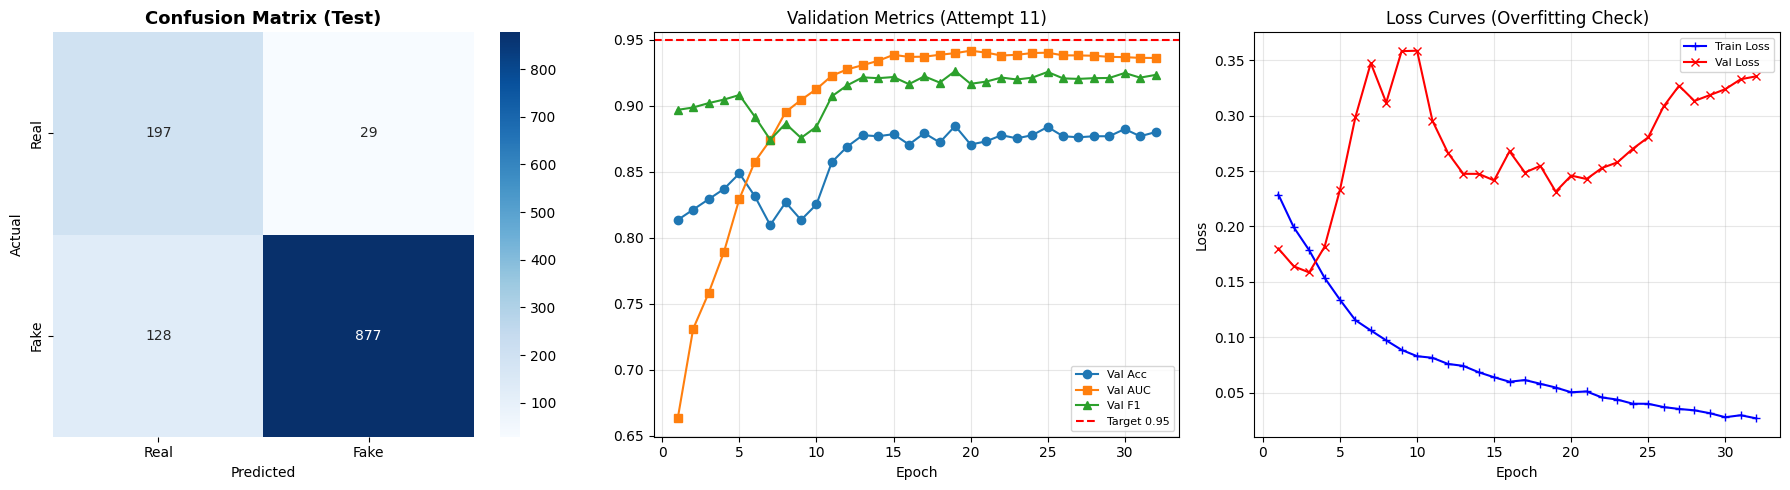

  ✅ Saved to /kaggle/working/results_v11.png


In [16]:
print('Loading best checkpoint (EMA weights) ...')
ckpt = torch.load(best_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model'])
best_thr = float(ckpt['thr'])
print(f'  ✅ Loaded | val AUC={ckpt["auc"]:.4f} | thr={best_thr:.2f}')

y_test, p_test, _ = infer_loader(model, test_loader, desc='Test')
test_m = compute_metrics(y_test, p_test, thr=best_thr)

print('\n' + '='*60)
print('  📊 TEST SET RESULTS')
print('='*60)
print(f'  Accuracy  : {test_m["acc"]:.4f}  {"🎯 TARGET MET!" if test_m["acc"] >= cfg.target_acc else "❌ Below target"}')
print(f'  F1 Score  : {test_m["f1"]:.4f}')
print(f'  ROC-AUC   : {test_m["auc"]:.4f}')
print(f'  Threshold : {best_thr:.2f}')
print('='*60)

pred_test = (p_test >= best_thr).astype(np.int32)
cm = confusion_matrix(y_test, pred_test)

print('\n  📈 Per-Dataset Breakdown:')
print('  ' + '-'*50)
for src in test_df['source'].unique():
    mask = test_df['source'].values == src
    if mask.sum() > 0:
        src_m = compute_metrics(y_test[mask], p_test[mask], thr=best_thr)
        n = mask.sum()
        print(f'  {src:<10}: Acc={src_m["acc"]:.4f} | AUC={src_m["auc"]:.4f} | '
              f'F1={src_m["f1"]:.4f} | n={n}')
print('  ' + '-'*50)

# ── Comparison vs all attempts ──
print('\n  📋 Comparison vs Previous Attempts:')
print('  ' + '-'*85)
print(f'  {"Metric":<15} {"Attempt 8":<15} {"Attempt 9":<15} {"Attempt 10":<15} {"Attempt 11":<15}')
print(f'  {"Val AUC":<15} {"0.5457":<15} {"0.9159":<15} {"0.9458":<15} {best_auc:<15.4f}')
print(f'  {"Test Acc":<15} {"~0.78":<15} {"~0.89":<15} {"0.9009":<15} {test_m["acc"]:<15.4f}')
print(f'  {"Test AUC":<15} {"~0.55":<15} {"~0.90":<15} {"0.9362":<15} {test_m["auc"]:<15.4f}')
print(f'  {"Test F1":<15} {"~0.55":<15} {"~0.93":<15} {"0.9383":<15} {test_m["f1"]:<15.4f}')
print(f'  {"Backbone":<15} {"EffNet-B3":<15} {"DeiT-Small":<15} {"DeiT-Small":<15} {"DeiT-Small":<15}')
print(f'  {"Frames":<15} {"8":<15} {"8":<15} {"8":<15} {"16":<15}')
print(f'  {"Fusion":<15} {"Concat":<15} {"Concat":<15} {"Concat":<15} {"CrossAttn":<15}')
print(f'  {"EMA":<15} {"No":<15} {"No":<15} {"No":<15} {"Yes (0.999)":<15}')
print(f'  {"Mixup":<15} {"No":<15} {"No":<15} {"No":<15} {"α=0.2":<15}')
print('  ' + '-'*85)

# ── Plots ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
axes[0].set_title('Confusion Matrix (Test)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

if len(history) > 0:
    hdf = pd.DataFrame(history)
    axes[1].plot(hdf['epoch'], hdf['val_acc'], 'o-', label='Val Acc')
    axes[1].plot(hdf['epoch'], hdf['val_auc'], 's-', label='Val AUC')
    axes[1].plot(hdf['epoch'], hdf['val_f1'],  '^-', label='Val F1')
    axes[1].axhline(cfg.target_acc, color='red', ls='--', label=f'Target {cfg.target_acc}')
    axes[1].set_title('Validation Metrics (Attempt 11)')
    axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

    axes[2].plot(hdf['epoch'], hdf['train_loss'], '+-', label='Train Loss', color='blue')
    axes[2].plot(hdf['epoch'], hdf['val_loss'],   'x-', label='Val Loss', color='red')
    axes[2].set_title('Loss Curves (Overfitting Check)')
    axes[2].set_xlabel('Epoch'); axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)
    axes[2].set_ylabel('Loss')

plt.tight_layout()
plt.savefig('/kaggle/working/results_v11.png', dpi=120, bbox_inches='tight')
plt.show()
print('  ✅ Saved to /kaggle/working/results_v11.png')

---
## 🎬 Section 13 — Single-Video Inference

In [17]:
def predict_from_pt(pt_path, model, img_size=224, num_frames=16, thr=0.5):
    model.eval()
    data   = torch.load(pt_path, map_location='cpu', weights_only=False)
    frames = data['frames'].numpy()

    # Select num_frames evenly spaced
    T = frames.shape[0]
    if T > num_frames:
        idxs = np.linspace(0, T - 1, num_frames, dtype=int)
        frames = frames[idxs]
    elif T < num_frames:
        pad = np.stack([frames[-1]] * (num_frames - T))
        frames = np.concatenate([frames, pad], axis=0)

    MEAN = np.array([0.485, 0.456, 0.406], np.float32)
    STD  = np.array([0.229, 0.224, 0.225], np.float32)
    x = frames.astype(np.float32) / 255.0
    x = (x - MEAN) / STD
    x = np.transpose(x, (0, 3, 1, 2))
    x = torch.tensor(x).unsqueeze(0).to(device)
    with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
        prob_fake = torch.sigmoid(model(x)).item()
    verdict = '🔴 FAKE' if prob_fake >= thr else '🟢 REAL'
    return {'pt_path': str(pt_path), 'prob_fake': round(prob_fake, 4),
            'prediction': verdict, 'threshold': round(thr, 2)}

example_path = test_df.iloc[0]['pt_path']
actual = '🔴 FAKE' if test_df.iloc[0]['label'] == 1 else '🟢 REAL'
result = predict_from_pt(example_path, model, cfg.img_size, cfg.num_frames, best_thr)

print('─'*55)
print('  🎬 Single Video Inference')
print('─'*55)
print(f'  File      : {Path(example_path).name}')
print(f'  Actual    : {actual}')
print(f'  Predicted : {result["prediction"]}')
print(f'  Fake prob : {result["prob_fake"]:.4f}')
correct = (result['prob_fake'] >= best_thr) == (test_df.iloc[0]['label'] == 1)
print(f'  Correct?  : {"✅ Yes" if correct else "❌ No"}')
print('─'*55)

───────────────────────────────────────────────────────
  🎬 Single Video Inference
───────────────────────────────────────────────────────
  File      : celebdf_0_00015.pt
  Actual    : 🟢 REAL
  Predicted : 🟢 REAL
  Fake prob : 0.0202
  Correct?  : ✅ Yes
───────────────────────────────────────────────────────


---
## 🎥 Section 14 — Raw .mp4 Video Inference

End-to-end inference from a raw `.mp4` file, including face detection, extraction, and prediction.

In [18]:
import cv2
import numpy as np

def predict_from_video(video_path, model, img_size=224, num_frames=16, thr=0.5):
    """Run inference on a raw video file (.mp4, .avi, etc.)"""
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

    def get_face_crop(frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.3, 5)
        if len(faces) == 0:
            H, W = frame.shape[:2]
            size = min(H, W)
            x1, y1 = (W - size) // 2, (H - size) // 2
            return cv2.resize(frame[y1:y1+size, x1:x1+size], (img_size, img_size))
        (x, y, w, h) = max(faces, key=lambda f: f[2] * f[3])
        H, W = frame.shape[:2]
        pad_w, pad_h = int(w * 0.2), int(h * 0.2)
        x1, y1 = max(0, x - pad_w), max(0, y - pad_h)
        x2, y2 = min(W, x + w + pad_w), min(H, y + h + pad_h)
        return cv2.resize(frame[y1:y2, x1:x2], (img_size, img_size))

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        print(f"❌ Could not read video: {video_path}")
        return None

    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    extracted = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret: break
        extracted.append(cv2.cvtColor(get_face_crop(frame), cv2.COLOR_BGR2RGB))
    cap.release()

    while len(extracted) < num_frames:
        extracted.append(extracted[-1])

    MEAN = np.array([0.485, 0.456, 0.406], np.float32)
    STD  = np.array([0.229, 0.224, 0.225], np.float32)
    x = np.array(extracted).astype(np.float32) / 255.0
    x = (x - MEAN) / STD
    x = np.transpose(x, (0, 3, 1, 2))
    x = torch.tensor(x).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        prob_fake = torch.sigmoid(model(x)).item()

    verdict = "🔴 FAKE" if prob_fake >= thr else "🟢 REAL"
    confidence = prob_fake if prob_fake >= thr else (1 - prob_fake)
    print("\n" + "═"*55)
    print("  🎬  VIDEO INFERENCE RESULTS")
    print("═"*55)
    print(f"  Verdict     : {verdict}")
    print(f"  Probability : {prob_fake:.4f}")
    print(f"  Confidence  : {confidence*100:.2f}%")
    print("═"*55)

    plt.figure(figsize=(15, 3))
    for i, img in enumerate(extracted[:8]):
        plt.subplot(1, 8, i+1)
        plt.imshow(img)
        plt.axis('off')
    plt.show()
    return prob_fake

# Usage:
# predict_from_video("/kaggle/input/your-video/test.mp4", model, thr=best_thr)

---
## 📝 Summary of Expected Outcomes

### Why Attempt 11 targets Face2Face and DFD:

1. **Temporal Context (16 frames)**: Face2Face relies on subtle expression manipulation. 16 frames (vs 8) provide a much richer temporal window to spot unnatural muscle movements.
2. **Cross-Attention Fusion**: Previously, spatial and temporal streams only combined at the very end. Now, they share information earlier, allowing the model to correlate "who is this" (spatial) with "how are they moving" (temporal).
3. **Multi-Scale Frequency**: DFD has actor replacements with varying blending artifact sizes. `k=3, 7, 15` high-pass filters capture these diverse scales better than the single `k=7` filter in Attempt 10.
4. **Mixup & EMA**: Deeper models overfit faster. Mixup creates synthetic interpolation distributions, while EMA acts as a temporal ensemble, smoothing out the noise.
5. **DFD Boost**: Explicitly forcing the sampler to pack 50% more DFD samples in an epoch forces the network to specialize in those subtle DFD patterns.

### Target metrics:
| Metric | Attempt 10 | Attempt 11 Target |
|---|---|---|
| Val AUC | ~0.94 | >0.95 |
| DFD AUC | ~0.65 | >0.80 |
| Face2Face AUC | ~0.80 | >0.85 |